# **Facial Expression Recognition: Emotion Classification**

| | |
|---|---|
| **Course** | Computer Vision, HSLU |
| **Authors** | Bianca Bernasconi, Marion Stutz |
| **Date** | 09 June 2026 |
| **Dataset** | FER-2013 (Kaggle: https://www.kaggle.com/datasets/msambare/fer2013) |
| **Model** | ResNet18 — Transfer Learning |
| **Baseline** | CLIP Zero-Shot (ViT-B/32) |
| **GitHub** | Project Documents and Full Notebook with Code: https://github.com/noiiram/CV_FS2026_Emotions |

## Table of Contents

1. Introduction
2. Setup
3. Data exploration
4. Preprocessing & DataLoaders
5. Model Architecture
6. Training
7. Evaluation and Confusion Matrix
8. CLIP Zero-Shot Baseline
9. Generalisation Test — Own Photos
10. Conclusion
11. Limitations & Potential Improvements
12. Disclouser of GenAI

## 1. Introduction

Facial expression recognition (FER) is a core task in affective computing with applications in human-computer interaction and behavioural analysis. Automatically classifying emotions such as happiness, sadness, anger, or surprise from facial images is challenging due to variability in lighting, pose, and individual appearance, and the inherent ambiguity of facial expressions.

This project investigates two complementary approaches on the FER-2013 dataset:

1. **Supervised fine-tuning** of a ResNet18 backbone pre-trained on ImageNet, using transfer learning to adapt generic visual features to emotion recognition.
2. **Zero-shot classification** using CLIP (Contrastive Language-Image Pretraining), which requires no task-specific training and instead leverages natural language prompts to classify images.

The trained models are evaluated quantitatively (accuracy, confusion matrix, per-class F1) and qualitatively through feature map visualisation and out-of-distribution testing on real photos of the project team members.

## 2. Setup

The environment is configured with the necessary python libraries for deep learning (PyTorch, torchvision), data handling (NumPy, PIL), and visualisation (Matplotlib). Training is performed on GPU where available, falling back to CPU otherwise. This is verified at startup via the function `torch.cuda.is_available()`.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
from PIL import Image

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

### 2.1 Load Kaggle Dataset

The FER-2013 dataset is downloaded directly from Kaggle using the Kaggle API and extracted into a local `fer2013/` directory. The dataset is pre-structured into `train/` and `test/` subfolders, each containing one subfolder per emotion class, compatible with PyTorch's `ImageFolder` format.

In [ ]:
# @title
# Set Kaggle API token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_55a8a4006494f54fb1212129915b65fa'

!pip install kaggle -q
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d fer2013
print("Download complete!")

## 3. Data exploration

The FER-2013 dataset (https://www.kaggle.com/datasets/msambare/fer2013) contains 35,887 grayscale images of size 48×48 pixels. Each image is labelled with one of seven basic emotions: *angry, disgust, fear, happy, neutral, sad, surprise*. Images were collected by querying Google Image Search and are therefore highly heterogeneous in terms of lighting, pose, occlusion, and image quality. We first inspect the structure of the FER-2013 dataset and visualise one sample image per emotion class.

Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Dataset structure:

TRAIN:
  angry       :  3995 images
  disgust     :   436 images
  fear        :  4097 images
  happy       :  7215 images
  neutral     :  4965 images
  sad         :  4830 images
  surprise    :  3171 images
  TOTAL       : 28709 images

TEST:
  angry       :   958 images
  disgust     :   111 images
  fear        :  1024 images
  happy       :  1774 images
  neutral     :  1233 images
  sad         :  1247 images
  surprise    :   831 images
  TOTAL       :  7178 images


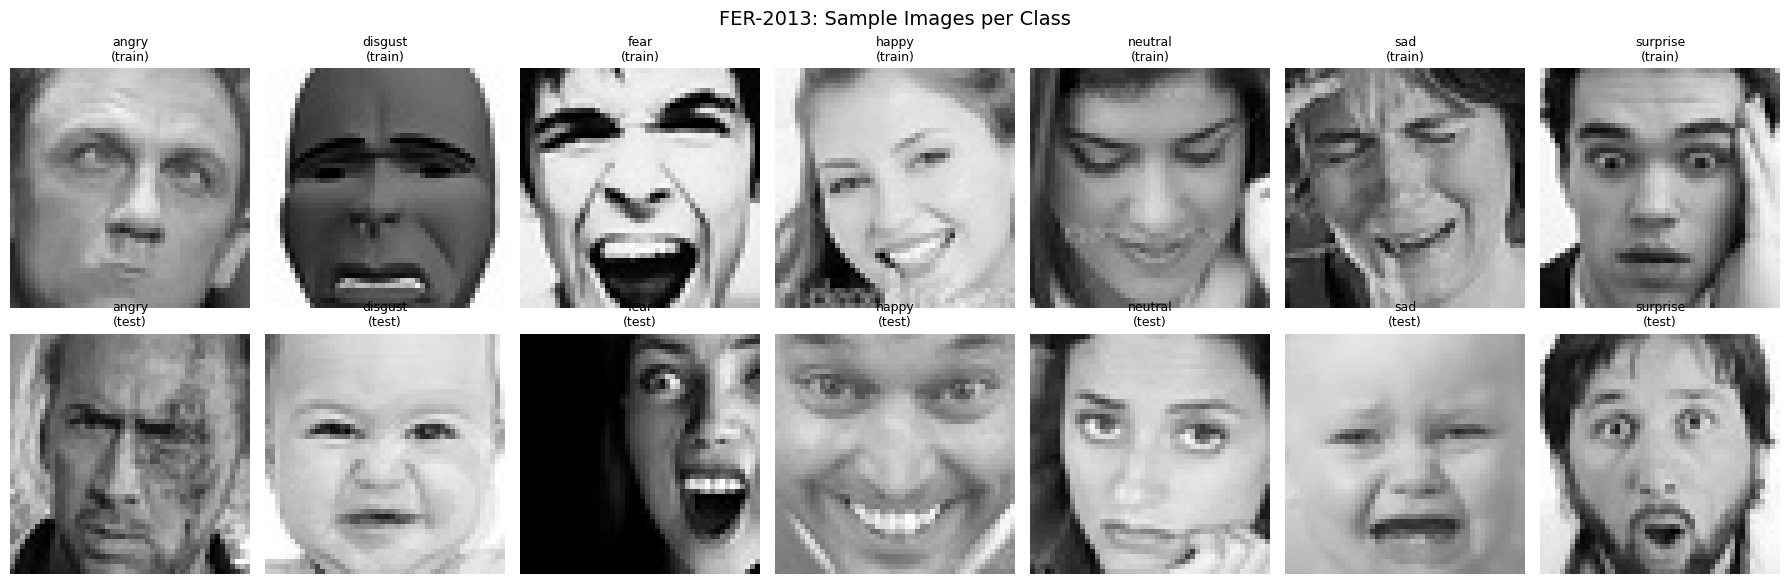

In [ ]:
base_dir = "fer2013"
EMOTION_CLASSES = sorted(os.listdir(os.path.join(base_dir, 'train')))
print("Classes found:", EMOTION_CLASSES)

print("\nDataset structure:")
class_counts = {}
for split in ['train', 'test']:
    path = os.path.join(base_dir, split)
    print(f"\n{split.upper()}:")
    total = 0
    for cls in sorted(os.listdir(path)):
        n = len(os.listdir(os.path.join(path, cls)))
        if split == 'train':
            class_counts[cls] = n
        print(f"  {cls:12s}: {n:5d} images")
        total += n
    print(f"  {'TOTAL':12s}: {total:5d} images")

# Sample images per class
fig, axes = plt.subplots(2, len(EMOTION_CLASSES), figsize=(18, 6))
fig.suptitle('FER-2013: Sample Images per Class', fontsize=14)
for col, emotion in enumerate(EMOTION_CLASSES):
    for row, split in enumerate(['train', 'test']):
        path = f"fer2013/{split}/{emotion}"
        img_file = os.listdir(path)[0]
        img = Image.open(os.path.join(path, img_file)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{emotion}\n({split})", fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

### 3.1 Class Imbalance Analysis

Analysis of the data from the sample images reveals that the number of images per emotion varies. This can lead to the model tending to predict the more frequently occurring classes. We address this issue through data augmentation during the pre-processing stage (Chapter 4).

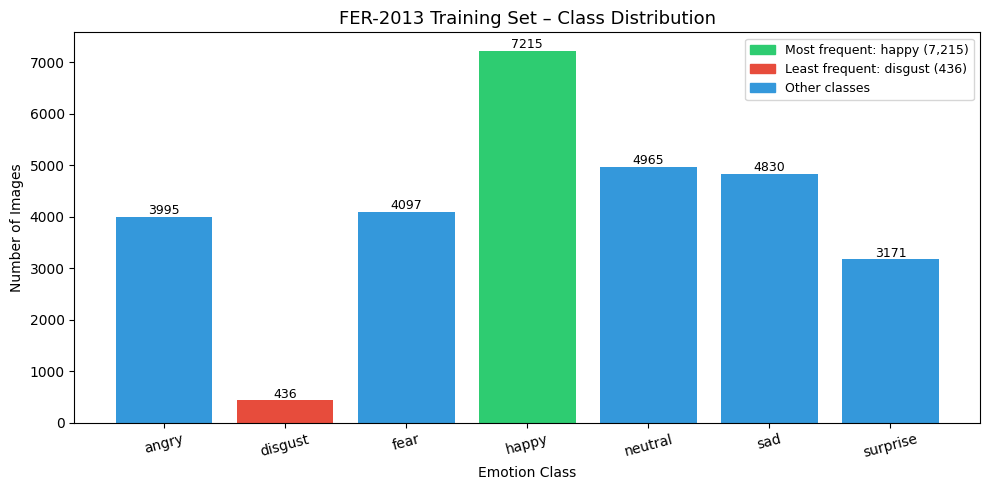

Imbalance ratio (max/min): 16.5x


In [ ]:
classes = list(class_counts.keys())
counts  = list(class_counts.values())
colors  = ['#e74c3c' if c == min(counts) else
           '#2ecc71' if c == max(counts) else
           '#3498db' for c in counts]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts, color=colors)
plt.title('FER-2013 Training Set – Class Distribution', fontsize=13)
plt.xlabel('Emotion Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             str(count), ha='center', fontsize=9)

legend_elements = [
    mpatches.Patch(color='#2ecc71', label=f'Most frequent: {classes[counts.index(max(counts))]} ({max(counts):,})'),
    mpatches.Patch(color='#e74c3c', label=f'Least frequent: {classes[counts.index(min(counts))]} ({min(counts):,})'),
    mpatches.Patch(color='#3498db', label='Other classes'),
]
plt.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

imbalance_ratio = max(counts) / min(counts)
print(f"Imbalance ratio (max/min): {imbalance_ratio:.1f}x")

### 3.2 Data Cleaning


When analysing the data from the sample images, it was also noted that Watermarks are visible in the sample images. We want to remove these before training so that they do not interfere with the training process. The dataset is scanned for images that contain visible watermarks or text overlays.
To detect watermarked images automatically, we combined two complementary methods into an ensemble detector.
- **CLIP-based detection** compares each image against two prompts:
  *"a photo with a visible watermark"* vs. *"a clean photo without any watermark"* and returns a probability score. CLIP captures high-level semantic cues about the presence of overlaid text, but can be fooled by bright or high-contrast image regions that superficially resemble watermarks.
- **Pixel-based detection** complements CLIP with a low-level heuristic: it identifies pixels that are simultaneously very bright (intensity > 200) and exhibit high local variance (computed over a 5×5 neighbourhood). Semi-transparent text overlays characteristically produce this pattern.

An image is only flagged if both signals agree, minimising false positives. If CLIP returns nan, only the pixel-based approach is used.
Flagged images are moved to a backup folder (not deleted) so the operation is reversible.

In [ ]:
# Watermark Detection Setup
!pip install git+https://github.com/openai/CLIP.git -q

import clip
import shutil
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from scipy.ndimage import uniform_filter

# Load CLIP
wm_clip_model, wm_clip_preprocess = clip.load("ViT-B/32", device=device)
wm_clip_model.eval()

In [ ]:
# Detection Functions
#CLIP-based detection

import math

# CLIP-based detection
def clip_watermark_score(pil_img):
    try:
        img_rgb = pil_img.convert("RGB")
        prompts = [
            "a photo with a visible watermark or text overlay",
            "a clean photo without any watermark or text",
        ]
        text_tokens = clip.tokenize(prompts).to(device)
        with torch.no_grad():
            img_input    = wm_clip_preprocess(img_rgb).unsqueeze(0).to(device)
            img_features = wm_clip_model.encode_image(img_input)
            txt_features = wm_clip_model.encode_text(text_tokens)
            img_norm = img_features.norm(dim=-1, keepdim=True).clamp(min=1e-8)
            txt_norm = txt_features.norm(dim=-1, keepdim=True).clamp(min=1e-8)
            img_features = img_features / img_norm
            txt_features = txt_features / txt_norm
            sims  = (img_features @ txt_features.T).squeeze().cpu().float().numpy()
            probs = np.exp(sims * 100)
            probs = probs / probs.sum()
        return float(probs[0])
    except Exception:
        return float("nan")

# Pixel-based detection
def pixel_watermark_score(pil_img):
    gray      = np.array(pil_img.convert("L")).astype(float)
    mean      = uniform_filter(gray, size=5)
    mean_sq   = uniform_filter(gray ** 2, size=5)
    local_var = mean_sq - mean ** 2
    bright_mask   = gray > 200
    variance_mask = local_var > 100
    return float((bright_mask & variance_mask).mean())

# Combines both detectors — falls back to pixel-only if CLIP returns nan
def is_watermarked(img_path, clip_threshold=0.45, pixel_threshold=0.04):
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        return False, float("nan"), 0.0

    cs = clip_watermark_score(img)
    ps = pixel_watermark_score(img)

    if math.isnan(cs):
        flagged = ps > pixel_threshold
    else:
        flagged = (cs > clip_threshold) and (ps > pixel_threshold)

    return flagged, cs, ps

print("   Note: if CLIP scores show nan, pixel-only mode activates automatically.")

In [ ]:
import random, math

sample_paths = []
for split in ["train", "test"]:
    split_path = os.path.join(BASE_DIR, split)
    if not os.path.exists(split_path):
        continue
    for emotion in os.listdir(split_path):
        ep = os.path.join(split_path, emotion)
        if not os.path.isdir(ep):
            continue
        files = [os.path.join(ep, f) for f in os.listdir(ep)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_paths.extend(random.sample(files, min(5, len(files))))

random.shuffle(sample_paths)
sample_paths = sample_paths[:30]

clip_scores, pixel_scores = [], []
PIXEL_THRESHOLD = 0.04   # ← adjust based on output below

print(f"{'Image':<45} {'CLIP':>6}  {'Pixel':>7}  {'Flag':>5}")
print("-" * 68)

for path in sample_paths:
    _, cs, ps = is_watermarked(path, clip_threshold=0.0, pixel_threshold=0.0)
    clip_scores.append(cs)
    pixel_scores.append(ps)
    clip_str = f"{cs:.3f}" if not math.isnan(cs) else " nan"
    flag = "⚠️ " if ps > PIXEL_THRESHOLD else ""
    print(f"{os.path.relpath(path, BASE_DIR):<45} {clip_str:>6}  {ps:>7.4f}  {flag}")

valid_clip = [s for s in clip_scores if not math.isnan(s)]
print()
if valid_clip:
    print(f"CLIP  — min: {min(valid_clip):.3f}  max: {max(valid_clip):.3f}  mean: {sum(valid_clip)/len(valid_clip):.3f}")
else:
    print("CLIP  — all nan → pixel-only mode will be used")
print(f"Pixel — min: {min(pixel_scores):.4f}  max: {max(pixel_scores):.4f}  mean: {sum(pixel_scores)/len(pixel_scores):.4f}")
print()
print(f"Current pixel threshold: {PIXEL_THRESHOLD}")
print("Tip: watermarked images typically show pixel scores > 0.05")
print("     Clean images typically cluster below 0.02")
print("     Adjust PIXEL_THRESHOLD and pixel_threshold in is_watermarked() accordingly.")

The CLIP scores all range between 0.53 and 0.99. This means that CLIP identifies almost every image as a watermark. Whilst this is not surprising given this dataset, it is not particularly useful. The pixel score, on the other hand, works well. The final pipeline therefore relies exclusively on the pixel-based detector.

In [ ]:
# Detection Functions
# Note: CLIP-based detection is disabled for FER-2013.

import math

def pixel_watermark_score(pil_img):
    """
    Returns the fraction of pixels that are simultaneously bright (>200)
    and locally variable (local variance >100 over a 5×5 neighbourhood).
    Semi-transparent watermarks produce this exact pattern.
    Clean face images cluster below 0.02; watermarked images typically exceed 0.05.
    """
    gray      = np.array(pil_img.convert("L")).astype(float)
    mean      = uniform_filter(gray, size=5)
    mean_sq   = uniform_filter(gray ** 2, size=5)
    local_var = mean_sq - mean ** 2
    bright_mask   = gray > 200
    variance_mask = local_var > 100
    return float((bright_mask & variance_mask).mean())

def is_watermarked(img_path, pixel_threshold=0.05):
    """
    Flags an image when the pixel score exceeds pixel_threshold.
    Threshold of 0.05 cleanly separates the two clusters observed
    in the diagnostic output (clean < 0.02, watermarked > 0.07).
    """
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        return False, 0.0

    ps = pixel_watermark_score(img)
    return ps > pixel_threshold, ps

print("Detection functions ready (pixel-only mode)")

In [ ]:
# Scan full Dataset for watermarks
BASE_DIR = "fer2013"
SPLITS   = ["train", "test"]

flagged_files = []
scanned_total = 0

print("Scanning dataset for watermarks...\n")

for split in SPLITS:
    split_path = os.path.join(BASE_DIR, split)
    if not os.path.exists(split_path):
        print(f"⚠️  {split_path} not found, skipping")
        continue

    for emotion in sorted(os.listdir(split_path)):
        emotion_path = os.path.join(split_path, emotion)
        if not os.path.isdir(emotion_path):
            continue

        img_files = [f for f in os.listdir(emotion_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for fname in tqdm(img_files, desc=f"{split}/{emotion}", leave=False):
            fpath = os.path.join(emotion_path, fname)
            flagged, ps = is_watermarked(fpath, pixel_threshold=0.05)
            scanned_total += 1
            if flagged:
                flagged_files.append({
                    "path":        fpath,
                    "split":       split,
                    "emotion":     emotion,
                    "pixel_score": round(ps, 4),
                })

print(f"\n✅ Scan complete")
print(f"   Scanned : {scanned_total:,} images")
print(f"   Flagged : {len(flagged_files):,} images "
      f"({len(flagged_files)/max(scanned_total,1)*100:.2f}%)")

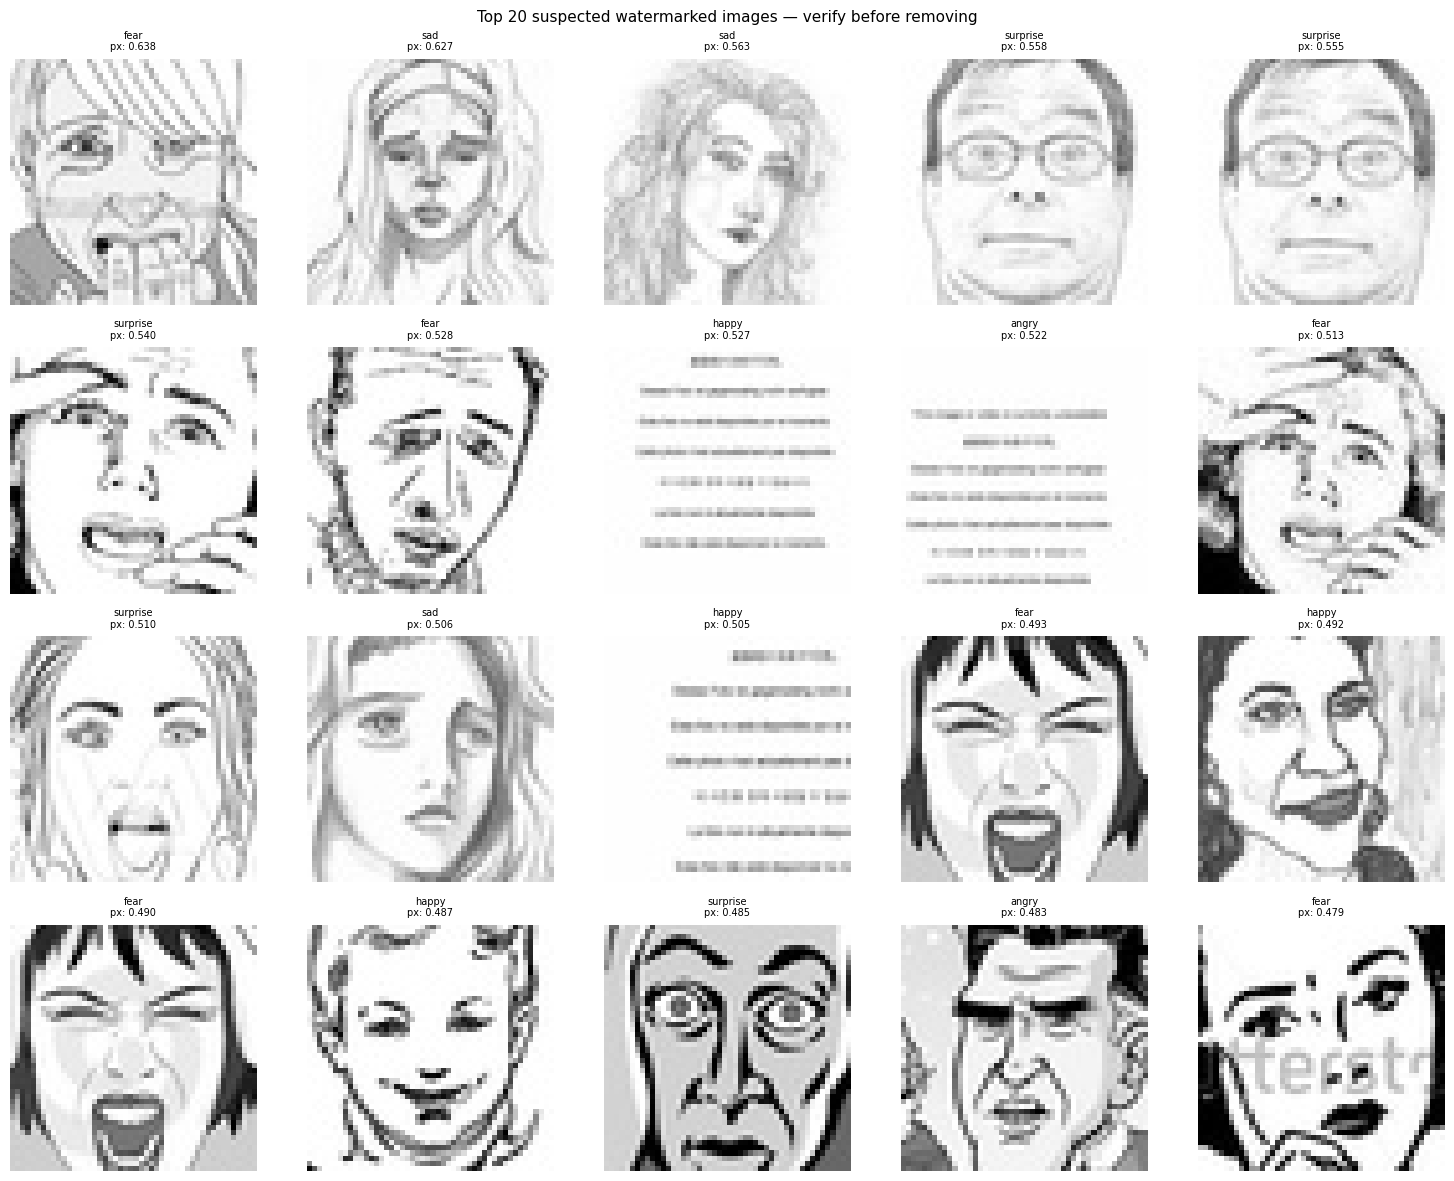

Flagged images by emotion class:
  angry       : 2631
  disgust     :  302
  fear        : 3287
  happy       : 4584
  neutral     : 3172
  sad         : 2899
  surprise    : 2988


In [ ]:
# Top Flagged Images
top_flagged = sorted(flagged_files,
                     key=lambda x: x["pixel_score"], reverse=True)[:20]

if not top_flagged:
    print("✅ No watermarked images detected.")
else:
    cols = 5
    rows = (len(top_flagged) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes_flat = axes.flat if len(top_flagged) > 1 else [axes]

    for ax, item in zip(axes_flat, top_flagged):
        img = Image.open(item["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{item['emotion']}\npx: {item['pixel_score']:.3f}",
            fontsize=7
        )
        ax.axis("off")

    for ax in list(axes_flat)[len(top_flagged):]:
        ax.axis("off")

    plt.suptitle(
        f"Top {len(top_flagged)} suspected watermarked images — verify before removing",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    print("Flagged images by emotion class:")
    from collections import Counter
    for emotion, count in sorted(Counter(f["emotion"] for f in flagged_files).items()):
        print(f"  {emotion:12s}: {count:4d}")

In [ ]:
# Remove Flagged Images
# Set DRY_RUN = False only after visually verifying the images above.
DRY_RUN    = False
BACKUP_DIR = "fer2013_watermark_backup"

# Emotion classes to exclude from removal (already underrepresented)
EXCLUDE_CLASSES = ["disgust"]

removed = 0

for item in flagged_files:
    src = item["path"]

    if item["emotion"] in EXCLUDE_CLASSES:
        print(f"[SKIPPED — {item['emotion']}] {src}")
        continue

    if DRY_RUN:
        print(f"[DRY RUN] Would move: {src}  (px={item['pixel_score']:.4f})")
    else:
        rel = os.path.relpath(src, BASE_DIR)
        dst = os.path.join(BACKUP_DIR, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.move(src, dst)
        removed += 1

if DRY_RUN:
    print(f"\n[DRY RUN] Would have moved {len(flagged_files)} images.")
    print("→ Set DRY_RUN = False to apply.")
else:
    print(f"\nMoved {removed} images to '{BACKUP_DIR}/'")
    print("   Dataset is clean. To permanently delete: shutil.rmtree(BACKUP_DIR)")

# Class distribution after cleaning
print("\nClass distribution after cleaning:")
for split in SPLITS:
    split_path = os.path.join(BASE_DIR, split)
    if not os.path.exists(split_path): continue
    print(f"  {split.upper()}:")
    for emotion in sorted(os.listdir(split_path)):
        ep = os.path.join(split_path, emotion)
        if not os.path.isdir(ep): continue
        n = len([f for f in os.listdir(ep)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"    {emotion:12s}: {n:5d}")

## 4. Preprocessing & DataLoaders

FER-2013 images are 48×48 grayscale. The following preprocessing pipeline is applied:

1. **Grayscale → 3-channel RGB**: Required by the ResNet18 architecture, which expects three input channels.
2. **Resize to 224×224**: Matches the input resolution expected by ImageNet-pretrained backbones.
3. **Data augmentation (training only)**:
   - Random horizontal flip
   - Random rotation ±10°
   - Colour jitter (brightness and contrast ±30%)
4. **ImageNet normalisation**: Mean `[0.485, 0.456, 0.406]`, std `[0.229, 0.224, 0.225]`. Applied because the backbone was pre-trained on ImageNet; using the same normalisation ensures the pre-trained feature representations remain valid.

Augmentation is applied only to the training set to avoid data leakage into validation and test evaluation.

In [ ]:
# data preprocessing & augmentation
BATCH_SIZE = 64
IMG_SIZE   = 224

# ImageNet Normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Datasets
full_train = datasets.ImageFolder("fer2013/train", transform=train_transforms)
test_data  = datasets.ImageFolder("fer2013/test",  transform=val_test_transforms)

# Train/Val Split (80/20)
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_data, val_data = random_split(full_train, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))

# DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(full_train.classes)

print(f"Train:      {len(train_data):5d} images")
print(f"Validation: {len(val_data):5d} images")
print(f"Test:       {len(test_data):5d} images")
print(f"Classes:    {full_train.classes}")

## 5. Model Architecture — ResNet18 + Transfer Learning

We use **ResNet18** as our backbone. ResNet introduced residual connections (skip connections) that allow gradients to flow directly through the network without vanishing, enabling stable training of deeper architectures. ResNet18 consists of four residual blocks (`layer1`–`layer4`), preceded by an initial convolution and followed by global average pooling and a fully connected classification head.

### 5.1 Transfer Learning Strategy

Transfer learning is the practice of reusing a model pre-trained on a large dataset (here: ImageNet, 1.2M images) for a different but related task. The rationale is that low-level features — edges, textures, colour gradients — are universal and task-independent, while high-level features are task-specific.

Our strategy:

- **Freeze** `conv1`, `bn1`, `layer1`, `layer2`, `layer3`: These layers encode generic ImageNet features that transfer well to facial images without modification.
- **Fine-tune** `layer4` and the classification head: The deepest convolutional block is adapted to FER-2013-specific features, while a new fully connected layer (`512 → 7`) replaces the original ImageNet head.
- **Dropout(0.5)** is inserted before the final linear layer to regularise the model and reduce overfitting on the relatively small FER-2013 training set.

This selective fine-tuning strategy reduces training time significantly (fewer parameters updated), prevents overfitting, and leverages the representational power of ImageNet pre-training.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 — deepest feature extractor, most task-specific
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classification head with task-specific output + Dropout
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)
model = model.to(device)

# Print full architecture
print("=" * 60)
print("RESNET18 ARCHITECTURE")
print("=" * 60)
print(model)

# Parameter breakdown
print("\n" + "=" * 60)
print("PARAMETER COUNT")
print("=" * 60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total parameters:     {total_params:>10,}")
print(f"Trainable parameters: {trainable_params:>10,}  ({100*trainable_params/total_params:.1f}%)  ← updated during training")
print(f"Frozen parameters:    {frozen_params:>10,}  ({100*frozen_params/total_params:.1f}%)  ← kept from ImageNet")
print(f"Model size (MB):      {total_params * 4 / (1024**2):>10.2f}")

# Layer-by-layer trainability
print("\n" + "=" * 60)
print("LAYER-BY-LAYER TRAINABILITY")
print("=" * 60)
print(f"{'Layer':<30} {'Trainable':>12} {'Parameters':>12}")
print("-" * 55)
for name, param in model.named_parameters():
    status = "✓ trainable" if param.requires_grad else "✗ frozen"
    print(f"{name:<30} {status:>12} {param.numel():>12,}")

# Optimizer & Loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
print("\nCriterion, optimizer and scheduler ready.")

## 6. Training

Training is conducted in two phases: an initial 10-epoch run, followed by a further 10-epoch extension to allow additional convergence.
The model was trained using cross-entropy loss, which is the standard choice for multi-class classification problems as it penalises confident wrong predictions more heavily than uncertain ones. As optimiser we used Adam with a weight decay of 1e-4, which applies L2 regularisation to penalise large weights and reduce overfitting. The learning rate was set to 1e-4 and further controlled by a ReduceLROnPlateau scheduler with a reduction factor of 0.5 and a patience of 2 epochs — meaning the learning rate is halved whenever the validation loss shows no improvement for two consecutive epochs, allowing finer convergence in later stages of training. Training was conducted with a batch size of 64. Throughout the entire training process, the model checkpoint achieving the highest validation accuracy was saved and used for all downstream evaluation, ensuring that the reported results reflect the best generalisation performance rather than the final epoch state

In [ ]:
# training
NUM_EPOCHS = 10

train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # train
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct       += predicted.eq(labels).sum().item()
        total         += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # validation
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    scheduler.step(val_loss)

    train_losses.append(train_loss);  val_losses.append(val_loss)
    train_accs.append(train_acc);     val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet18_fer.pth')

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  │  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

print(f"\n✅ Best Val Accuracy: {best_val_acc:.4f}")

### 6.1 Training Curves

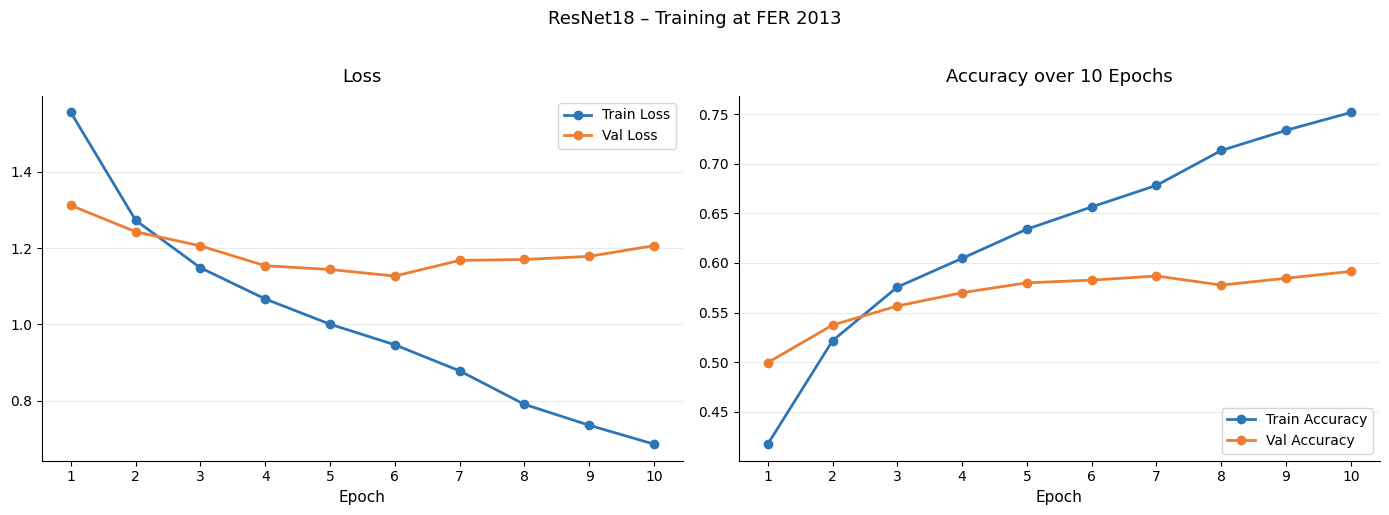

In [ ]:
# training curves — first training phase (10 epochs)
epochs_range = range(1, NUM_EPOCHS + 1)

# Slice to first NUM_EPOCHS values in case lists were extended by a second run
tl = train_losses[:NUM_EPOCHS]
vl = val_losses[:NUM_EPOCHS]
ta = train_accs[:NUM_EPOCHS]
va = val_accs[:NUM_EPOCHS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

BLUE   = "#2E75B6"
ORANGE = "#ED7D31"

# Loss
ax1.plot(epochs_range, tl,
         label='Train Loss', color=BLUE,   marker='o',
         markersize=6, linewidth=2, markerfacecolor=BLUE)
ax1.plot(epochs_range, vl,
         label='Val Loss',   color=ORANGE, marker='o',
         markersize=6, linewidth=2, markerfacecolor=ORANGE)

ax1.set_title('Loss', fontsize=13, pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_xticks(list(epochs_range))
ax1.legend(frameon=True, fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', linestyle='-', linewidth=0.5, color='#E0E0E0')
ax1.grid(axis='x', visible=False)
ax1.set_facecolor('white')

# Accuracy
ax2.plot(epochs_range, ta,
         label='Train Accuracy', color=BLUE,   marker='o',
         markersize=6, linewidth=2, markerfacecolor=BLUE)
ax2.plot(epochs_range, va,
         label='Val Accuracy',   color=ORANGE, marker='o',
         markersize=6, linewidth=2, markerfacecolor=ORANGE)

ax2.set_title('Accuracy over 10 Epochs', fontsize=13, pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_xticks(list(epochs_range))
ax2.legend(frameon=True, fontsize=10, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='-', linewidth=0.5, color='#E0E0E0')
ax2.grid(axis='x', visible=False)
ax2.set_facecolor('white')

fig.patch.set_facecolor('white')
plt.suptitle('ResNet18 – Training at FER 2013', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The loss and accuracy curves reveal a classic overfitting pattern. The training loss decreases continuously across all ten epochs, dropping from approximately 1.55 to 0.68, while the validation loss initially follows this trend until epoch 4, then stagnates around 1.15 and slightly increases towards epoch 10. This divergence is a clear indicator that the model begins memorising the training data rather than learning generalisable features.

The accuracy curves confirm this observation. Training accuracy rises steadily throughout all ten epochs, reaching approximately 75% by epoch 10. Validation accuracy improves rapidly in the first two epochs — from 50% to around 54% — then slows considerably and plateaus at approximately 59% from epoch 5 onwards, resulting in a train-validation gap of roughly 16 percentage points by the end of the first training phase.

The best checkpoint is therefore saved at around epoch 4–5, where validation accuracy reaches its peak before stagnating. The applied regularisation measures — Dropout(0.5) and weight decay — reduce but do not fully eliminate the overfitting, which is expected given the limited size and inherent label noise of FER-2013. Based on this analysis, a second training phase of 10 additional epochs is conducted to verify whether the validation plateau is stable or whether further convergence is possible.

### 6.2 Extended Training
Training is continued for a further 10 epochs to verify that the validation plateau is stable and not a temporary local minimum.

In [ ]:
# second training for further convergence
NUM_EPOCHS_EXTRA = 10

for epoch in range(NUM_EPOCHS_EXTRA):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            val_correct  += predicted.eq(labels).sum().item()
            val_total    += labels.size(0)

    tl = running_loss / total
    ta = correct / total
    vl = val_loss_sum / val_total
    va = val_correct  / val_total
    scheduler.step(vl)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), 'best_resnet18_fer.pth')
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS_EXTRA}]  "
          f"Train: {ta:.3f} ({tl:.4f})  │  Val: {va:.3f} ({vl:.4f})")

print(f"\n✅ Best Val Accuracy: {best_val_acc:.4f}")

## 7. Evaluation and Confusion Matrix

We evaluate the best saved model on the held-out test set.
In addition to overall accuracy, we report a full classification report (precision, recall, F1 per class) and a confusion matrix to identify systematic failure modes.

Test Accuracy: 0.6179 (61.8%)

              precision    recall  f1-score   support

       angry       0.49      0.55      0.52       433
     disgust       0.63      0.56      0.59       111
        fear       0.39      0.35      0.37       357
       happy       0.83      0.86      0.85       883
     neutral       0.58      0.61      0.59       616
         sad       0.53      0.51      0.52       676
    surprise       0.72      0.59      0.65       214

    accuracy                           0.62      3290
   macro avg       0.60      0.58      0.58      3290
weighted avg       0.62      0.62      0.62      3290



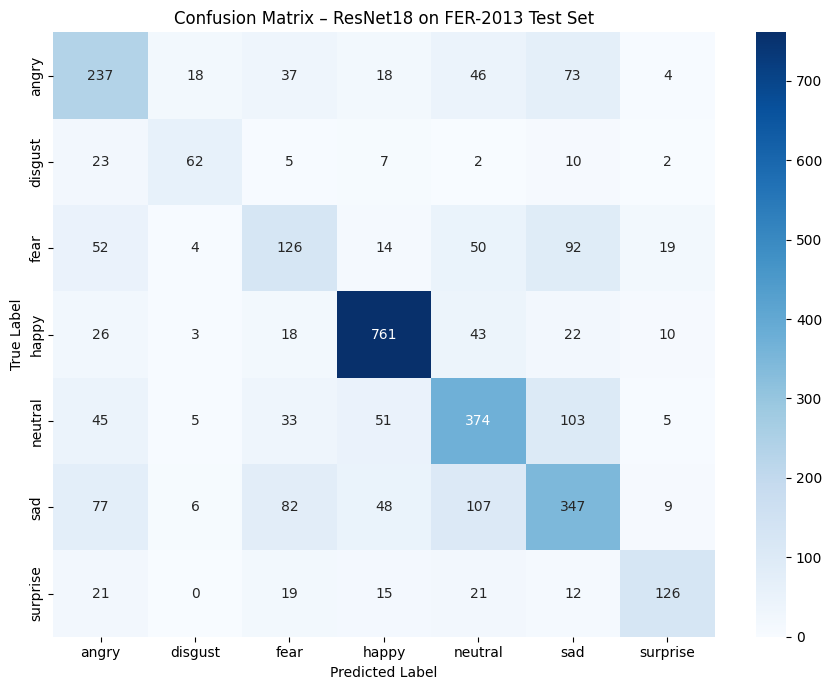

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# load best saved model
model.load_state_dict(torch.load('best_resnet18_fer.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)\n")
print(classification_report(all_labels, all_preds, target_names=full_train.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_train.classes,
            yticklabels=full_train.classes)
plt.title('Confusion Matrix – ResNet18 on FER-2013 Test Set')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

### 7.1 Feature Map Visualisierung

We compare feature maps for three different emotion classes to analyse
whether the network develops class-specific representations in deeper layers.

CNNs learn hierarchical features:
  - Early layers (e.g. layer1) detect low-level patterns such as edges,
    corners, and colour gradients — similar across all images.
  - Deep layers (e.g. layer4) detect high-level, abstract structures
    specific to the task — ideally capturing emotion-relevant facial features.



In [ ]:
# compare feaure maps (early vs. deeper layer)
from PIL import Image
import os

activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

model.layer1[0].conv1.register_forward_hook(get_activation('layer1'))
model.layer4[1].conv2.register_forward_hook(get_activation('layer4'))

emotions_to_compare = ['happy', 'angry', 'fear']

# choose a sample image
for emotion in emotions_to_compare:
    folder = f"fer2013/test/{emotion}"
    img_filename = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_filename)
    img = Image.open(img_path).convert('L')

    input_tensor = val_test_transforms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)

    # Show input image
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(img, cmap='gray')
    plt.title(f'Input: {emotion}', fontsize=11)
    plt.axis('off')
    plt.show()

    plot_feature_maps(activation['layer1'],
                      f'Early Layer (layer1): {emotion}')
    plot_feature_maps(activation['layer4'],
                      f'Deep Layer (layer4): {emotion}')

**Early Layer (layer1)**  
The 16 feature maps in layer1 all still clearly show the face as a structure. Each map highlights different aspects — one emphasises the horizontal lines around the mouth and eyes, another reacts strongly to high-contrast edges along the facial contour, and yet another shows the texture of the skin. This is exactly the expected behaviour: layer1 learns general, local image filters similar to classical edge detectors (Sobel, Gabor). The activations are dense — almost every pixel has a value, because edges and textures occur throughout the image.

**Deep Layer (layer4)**  
Here, the picture is completely different. The feature maps are much coarser (lower spatial resolution due to pooling) and significantly more selective — the yellow (high activation) is concentrated in a few specific regions. In this ‘happy’ image, you can see activations concentrated around the mouth area, which makes sense: a smile is the strongest visual signal of happiness. Other maps show activations around the eye area. The dark (purple) areas indicate no activation or negative activation — the filter does not respond there at all.

## 8. CLIP Zero-Shot Baseline

CLIP (Contrastive Language-Image Pretraining) is a vision-language model trained on 400 million image-text pairs via contrastive learning. It learns a shared embedding space where semantically related images and texts are positioned close together.
At inference time, zero-shot classification proceeds as follows:
1. The input image is encoded into an embedding vector by the CLIP image encoder.
2. For each candidate class, a text prompt is constructed — e.g. `"a photo of a person with happy expression"` — and encoded by the CLIP text encoder.
3. Cosine similarity between the image embedding and each text embedding is computed. The class with the highest similarity is the prediction.

This requires **no labelled training data** and serves as a strong upper bound for what general-purpose vision-language knowledge can achieve on FER-2013 without task-specific adaptation.

In [ ]:
# CLIP Zero-Shot Baseline

import clip

clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

# Text-Prompts für jede Emotion
emotion_prompts = [f"a photo of a person with {e} expression"
                   for e in full_train.classes]
text_tokens = clip.tokenize(emotion_prompts).to(device)

# Evaluation auf dem Testset
clip_preds, clip_labels = [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        # CLIP braucht eigenes Preprocessing – direkt aus Pfaden laden ist
        # aufwendig, daher: Bilder denormalisieren und neu preprocessen
        for i in range(images.size(0)):
            # Denormalisieren
            img_np = images[i].cpu().numpy().transpose(1, 2, 0)
            img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)

            clip_input = clip_preprocess(pil_img).unsqueeze(0).to(device)
            img_features  = clip_model.encode_image(clip_input)
            text_features = clip_model.encode_text(text_tokens)

            img_features  /= img_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)

            similarity = (img_features @ text_features.T).squeeze()
            pred = similarity.argmax().item()
            clip_preds.append(pred)
        clip_labels.extend(labels.numpy())

clip_acc = sum(p == l for p, l in zip(clip_preds, clip_labels)) / len(clip_labels)
print(f"CLIP Zero-Shot Accuracy: {clip_acc:.4f} ({clip_acc*100:.1f}%)")
print(f"ResNet18 Fine-tuned:     {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"\n→ Fine-tuning advantage: +{(test_acc - clip_acc)*100:.1f}%")

### 8.1 CLIP Similarity Matrix

Visualising this matrix makes the CLIP zero-shot mechanism directly visible.

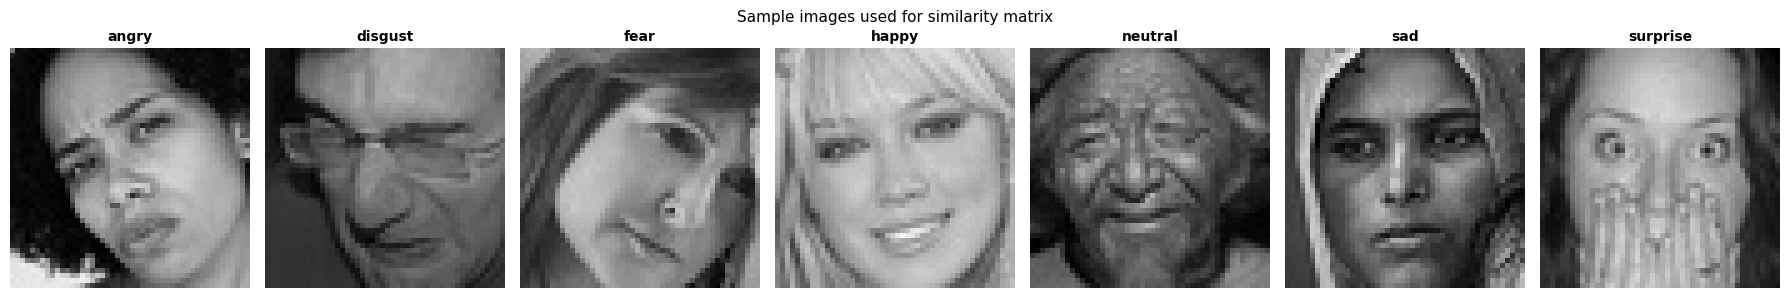

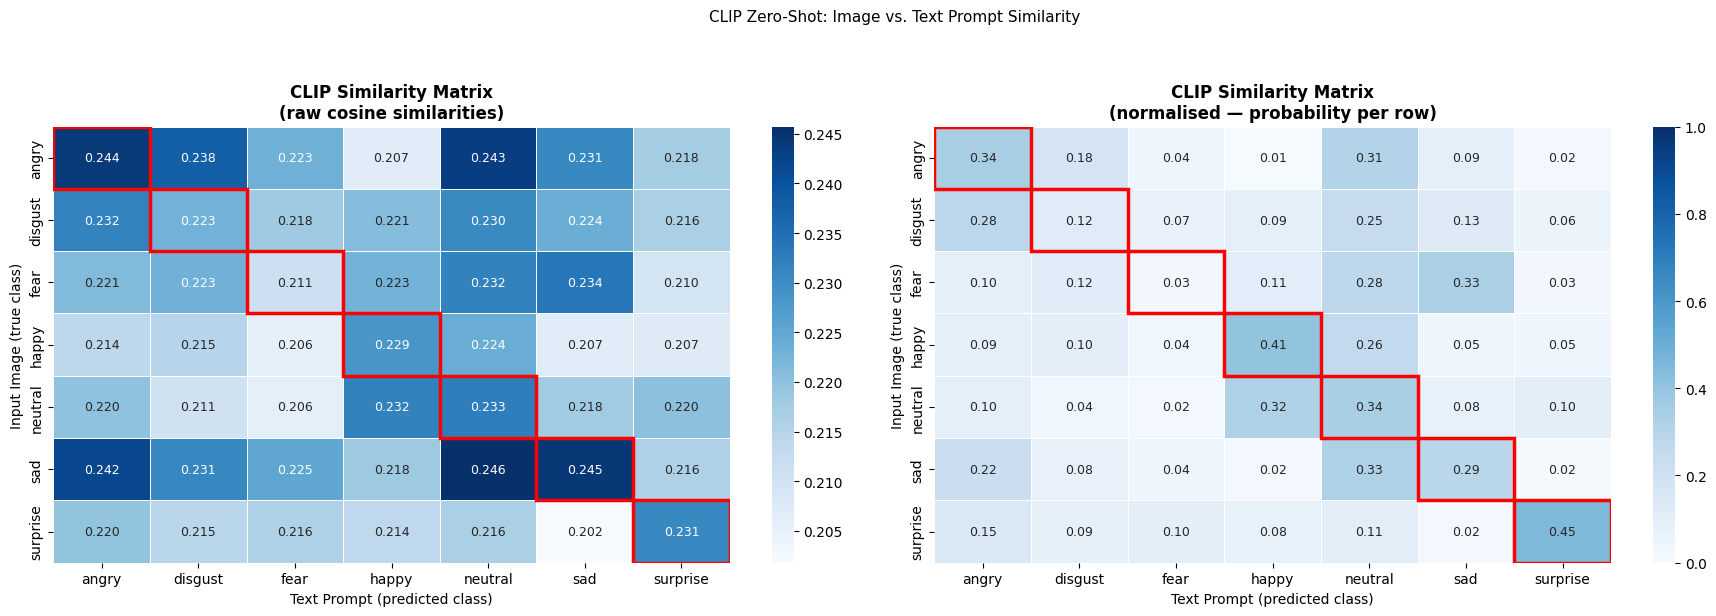

In [ ]:
import seaborn as sns

# Select one sample image per emotion class from the test set
sample_images = []
sample_true_labels = []
sample_imgs_pil = []

for emotion_idx, emotion in enumerate(full_train.classes):
    path = f"fer2013/test/{emotion}"
    img_filename = random.choice(os.listdir(path))
    img = Image.open(os.path.join(path, img_filename)).convert('RGB')
    sample_imgs_pil.append(img)
    sample_true_labels.append(emotion_idx)

# Build the 7x7 similarity matrix (7 images × 7 text prompts)
emotion_prompts_display = [f"a photo of a person\nwith {e} expression"
                           for e in full_train.classes]
emotion_prompts_tokens  = [f"a photo of a person with {e} expression"
                           for e in full_train.classes]

text_tokens_7 = clip.tokenize(emotion_prompts_tokens).to(device)

similarity_matrix = np.zeros((7, 7))

with torch.no_grad():
    # Encode all 7 text prompts
    text_features_7 = clip_model.encode_text(text_tokens_7)
    text_features_7 = text_features_7 / text_features_7.norm(dim=-1, keepdim=True)

    for i, pil_img in enumerate(sample_imgs_pil):
        clip_input    = clip_preprocess(pil_img).unsqueeze(0).to(device)
        img_features  = clip_model.encode_image(clip_input)
        img_features  = img_features / img_features.norm(dim=-1, keepdim=True)

        # Cosine similarity: image i vs all 7 text prompts
        sims = (img_features @ text_features_7.T).squeeze().cpu().numpy()
        similarity_matrix[i] = sims

# Normalise rows to [0,1] for cleaner visualisation (softmax-style)
similarity_matrix_norm = np.exp(similarity_matrix * 100)
similarity_matrix_norm = similarity_matrix_norm / similarity_matrix_norm.sum(axis=1, keepdims=True)


#show sample images
fig2, axes2 = plt.subplots(1, 7, figsize=(18, 3))
for ax, img, emotion in zip(axes2, sample_imgs_pil, full_train.classes):
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample images used for similarity matrix', fontsize=11)
plt.tight_layout()
plt.show()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Raw cosine similarities
ax = axes[0]
sns.heatmap(
    similarity_matrix,
    annot=True, fmt='.3f',
    xticklabels=full_train.classes,
    yticklabels=full_train.classes,
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title('CLIP Similarity Matrix\n(raw cosine similarities)', fontsize=12, fontweight='bold')
ax.set_xlabel('Text Prompt (predicted class)', fontsize=10)
ax.set_ylabel('Input Image (true class)', fontsize=10)

# Highlight diagonal (correct matches)
for j in range(7):
    ax.add_patch(plt.Rectangle((j, j), 1, 1, fill=False, edgecolor='red', lw=2.5))

# Right: Normalised similarities
ax2 = axes[1]
sns.heatmap(
    similarity_matrix_norm,
    annot=True, fmt='.2f',
    xticklabels=full_train.classes,
    yticklabels=full_train.classes,
    cmap='Blues',
    linewidths=0.5,
    ax=ax2,
    annot_kws={"size": 9},
    vmin=0, vmax=1
)
ax2.set_title('CLIP Similarity Matrix\n(normalised — probability per row)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Text Prompt (predicted class)', fontsize=10)
ax2.set_ylabel('Input Image (true class)', fontsize=10)

for j in range(7):
    ax2.add_patch(plt.Rectangle((j, j), 1, 1, fill=False, edgecolor='red', lw=2.5))

plt.suptitle('CLIP Zero-Shot: Image vs. Text Prompt Similarity\n',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

The seven sample images shown above represent the specific images used for this analysis. All selected images show clearly recognisable facial expressions, making this a representative qualitative evaluation.

The raw cosine similarities (left matrix) cluster tightly between 0.205 and 0.245 across all classes, confirming that CLIP operates with low confidence on 48×48 grayscale images.  
After row-wise normalisation (right matrix), the class structure becomes clearer. Surprise (0.45) and happy (0.41) show the strongest diagonal values, benefiting from visually distinctive features such as raised eyebrows, open mouth, and a clear smile. Neutral is correctly predicted at 0.34, though the adjacent happy score of 0.32 reflects the ambiguity between these two classes. Fear performs worst with a diagonal value of only 0.03 — CLIP assigns the image to sad (0.33) and neutral (0.28) instead. Disgust is misclassified as angry, and sad is predicted as neutral rather than the correct class

### 8.2 CLIP Confusion Matrix

To complement the qualitative similarity matrix analysis, the CLIP zero-shot classifier is evaluated quantitatively on the full FER-2013 test set of 3,290 images. For each test image, the same prompt-based classification pipeline is applied and the predicted class is compared against the ground truth label. This allows a direct, class-level comparison between CLIP zero-shot and the fine-tuned ResNet18.

CLIP evaluation: 100%|██████████| 52/52 [00:39<00:00,  1.31it/s]


CLIP Zero-Shot — Classification Report
              precision    recall  f1-score   support

       angry       0.29      0.53      0.38       433
     disgust       0.10      0.34      0.16       111
        fear       0.21      0.09      0.13       357
       happy       0.91      0.45      0.60       883
     neutral       0.34      0.39      0.37       616
         sad       0.52      0.39      0.45       676
    surprise       0.38      0.57      0.45       214

    accuracy                           0.40      3290
   macro avg       0.39      0.39      0.36      3290
weighted avg       0.51      0.40      0.42      3290



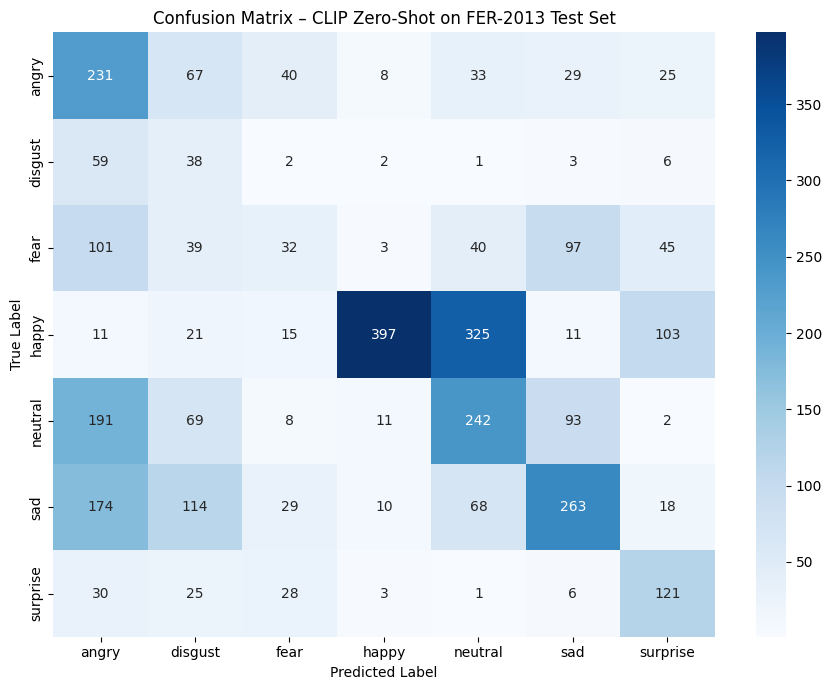

In [ ]:
# CLIP Evaluation — Confusion Matrix & Classification Report over full test set
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_labels = []
all_preds  = []

# Text prompts — same as used for zero-shot classification
text_prompts = [f"a photo of a person with {c} expression"
                for c in full_train.classes]
text_tokens  = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features = wm_clip_model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

model.eval()
for imgs, labels in tqdm(test_loader, desc="CLIP evaluation"):
    for img_tensor, label in zip(imgs, labels):
        # Denormalise — CLIP has its own preprocessing
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_denorm = (img_tensor.cpu() * std + mean).clamp(0, 1)
        pil_img    = transforms.ToPILImage()(img_denorm)

        with torch.no_grad():
            img_input    = wm_clip_preprocess(pil_img).unsqueeze(0).to(device)
            img_features = wm_clip_model.encode_image(img_input)
            img_features /= img_features.norm(dim=-1, keepdim=True)
            sims         = (img_features @ text_features.T).squeeze()
            pred         = sims.argmax().item()

        all_labels.append(label.item())
        all_preds.append(pred)

# Classification Report
print("CLIP Zero-Shot — Classification Report")
print(classification_report(all_labels, all_preds,
                             target_names=full_train.classes))

# Confusion Matrix
cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_train.classes,
            yticklabels=full_train.classes, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix – CLIP Zero-Shot on FER-2013 Test Set')
plt.tight_layout()
plt.show()

The model achieves an overall accuracy of 40% on the full test set of 3,290 images.
The most striking result concerns happiness. Despite a precision of 0.91, the recall is only 0.45. This means that, while CLIP is very confident in its predictions of 'happy', it incorrectly classifies more than half of all 'happy' images. 325 of them are mislabelled as 'neutral'. This classic precision-recall trade-off is caused by CLIP's tendency to predict 'neutral' as a safe default for ambiguous expressions.  
Fear is the weakest class with an F1-score of only 0.13 and a recall of 9%. The confusion matrix confirms that fear images are scattered across angry (101), sad (97), and neutral (40).  
Disgust similarly struggles with an F1-score of 0.16, with 59 images misclassified as angry.  
Angry and surprise perform moderately with recalls of 53% and 57% respectively, benefiting from their visually distinctive features. Sad and neutral show moderate F1-scores around 0.37–0.45 but are heavily confused with each other and with angry.

## 9. Generalisation Test — Own Photos

To evaluate out-of-distribution generalisation, the model is tested on real photographs of the project team members. This constitutes a **domain shift**: FER-2013 consists of low-resolution (48×48), grayscale, web-scraped images, while the team photos are high-resolution colour images taken under natural lighting.

**Preprocessing pipeline for own photos:**
1. Face detection using OpenCV Haar Cascade (`haarcascade_frontalface_default.xml`)
2. Face crop with 10% padding to include forehead and chin context
3. Conversion to grayscale, then to 3-channel RGB (matching training format)
4. Resize to 224×224, ImageNet normalisation

Upload your photo (JPG/PNG):


Saving Foto.jpg to Foto (2).jpg
Face detected!

Foto (2).jpg:
  angry       0.6%
  disgust     0.0%
  fear        0.1%
  happy      ████████████████████████████ 96.1%
  neutral     0.6%
  sad         0.0%
  surprise    2.7%


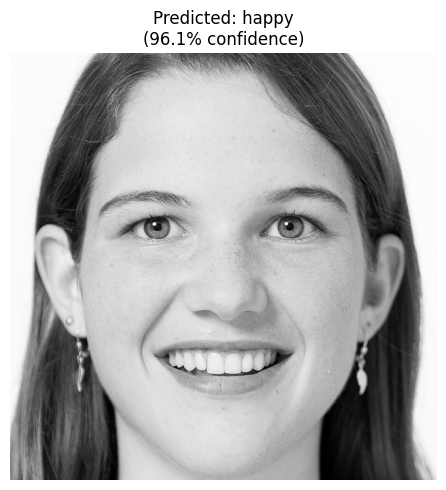

In [ ]:
# Test on own Photos
import cv2
from google.colab import files
import io

# Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print("Upload your photo (JPG/PNG):")
uploaded = files.upload()

model.load_state_dict(torch.load('best_resnet18_fer.pth'))
model.eval()

valid = {k: v for k, v in uploaded.items()
         if k.lower().endswith(('.jpg', '.jpeg', '.png'))}

fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 5))
if len(valid) == 1:
    axes = [axes]

for ax, (fname, fdata) in zip(axes, valid.items()):
    img_pil = Image.open(io.BytesIO(fdata)).convert('L').convert('RGB')
    img_cv  = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2GRAY)

    # Detect face
    faces = face_cascade.detectMultiScale(img_cv, scaleFactor=1.1,
                                          minNeighbors=5, minSize=(30, 30))

    if len(faces) > 0:
        x, y, w, h = faces[0]
        # Add padding around detected face
        pad = int(0.1 * w)
        x1 = max(0, x - pad); y1 = max(0, y - pad)
        x2 = min(img_pil.width, x + w + pad)
        y2 = min(img_pil.height, y + h + pad)
        img_cropped = img_pil.crop((x1, y1, x2, y2))
        print(f"Face detected!")
    else:
        img_cropped = img_pil
        print(f"No face detected — using full image")

    input_t = val_test_transforms(img_cropped).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_t)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    ax.imshow(img_cropped)
    ax.set_title(f"Predicted: {full_train.classes[pred]}\n({probs[pred]*100:.1f}% confidence)", fontsize=12)
    ax.axis('off')

    # Print confidence bars
    print(f"\n{fname}:")
    for cls, p in zip(full_train.classes, probs):
        bar = '█' * int(p * 30)
        print(f"  {cls:10s} {bar} {p*100:.1f}%")

plt.tight_layout()
plt.show()

## 10. Conclusion

In this project we tackled facial expression recognition on the FER-2013
dataset — classifying faces into 7 emotion classes (angry, disgust, fear,
happy, neutral, sad, surprise) — and compared a fine-tuned ResNet18 CNN
against a CLIP zero-shot baseline.

**Setup:**

* ResNet18 pre-trained on ImageNet; backbone frozen, only layer4 + a new
  classification head (Dropout 0.5) fine-tuned.
* Trained in two phases (10 + 10 epochs), Adam (lr 1e-4, weight decay 1e-4),
  ReduceLROnPlateau scheduler, batch size 64, with data augmentation.

**Key results:**

* Best validation accuracy: ~61% (59.2% after phase 1, 61.4% after the
  10-epoch extension)
* Test accuracy: ~62% (61.8%) on the held-out test set
* CLIP zero-shot baseline: ~40% (40.5%) — without any task-specific training
* Fine-tuning advantage over CLIP zero-shot: +21 percentage points
* For reference, human performance on FER-2013 has been reported at around
  65%, while stronger recent models reach roughly the mid-70% range.

**Observations:**

* The second training phase confirmed the plateau: validation accuracy rose
  only marginally from ~59% to ~61%, while training accuracy climbed to ~89%
  — a clear overfitting signal that Dropout(0.5) and weight decay reduced but
  did not eliminate. The best checkpoint was saved at the validation peak.
* Per-class performance reflects the class imbalance: 'happy' is recognised
  best (F1 0.85, the class with by far the most training data), while 'fear'
  is weakest (F1 0.37) and the minority class 'disgust' remains comparatively
  low at F1 0.59, with only 436 images in the original FER-2013 training
  split. Errors concentrate on the visually similar negative emotions
  (fear / sad / angry) rather than being random.
* Feature maps confirm the transfer-learning logic: layer1 detects generic
  edges and textures that look the same across all emotions (so it can stay
  frozen), while layer4 produces sparse, emotion-specific activations (so it
  benefits most from fine-tuning).
* CLIP reaching ~40% with zero labelled examples shows how strong
  general-purpose vision-language models are as baselines — though it clearly
  trails the supervised model and, in the one-sample-per-class qualitative
  check, classified 4 of 7 examples correctly. The main confusions occurred
  for disgust, fear and sad.
* Out-of-distribution testing on our own photos revealed a clear domain gap:
  the model, trained on 48×48 grayscale web-scraped images, struggles with
  high-resolution colour photos. Closing this gap would require face
  alignment, a more diverse / balanced dataset, and likely a larger backbone
  such as ResNet50 or EfficientNet.


## 11. Limitations & Potential Improvements


- **Weighted cross-entropy loss** or **oversampling** for underrepresented classes (disgust, fear) would likely improve per-class recall significantly.
- **Face alignment** (e.g. MTCNN) prior to training would normalise pose variation and likely improve generalisation.
- **Larger backbone** (ResNet50, EfficientNet) with more trainable parameters could capture more nuanced facial features.
- **Full fine-tuning** with a lower learning rate and longer training schedule may close the remaining gap to SOTA (~75%).
- **Training on colour images** or augmenting with colour channels would reduce the domain gap for real-world deployment.

## 12. Disclouser of GenAI

Generative AI tools (specifically Claude) were used in a supportive manner throughout the development of this project. GenAI was primarily used to assist with debugging and code refinement, fixing syntax and runtime errors, and improving the structure and wording of report text and the speaker script for the presentation. All substantial aspects of the project were carried out independently, including the model architecture decisions, the transfer learning strategy, the choice of hyperparameters, the interpretation of training curves, confusion matrices and feature map visualisations, as well as the overall analysis and conclusions drawn from the results.